## PATE Privacy Accounting Implementation

This section implements the legacy Laplace Report NoisyMax moments accountant and integrates it into the notebook for calculating privacy guarantees for PATE (Private Aggregation of Teacher Ensembles).

In [ ]:
# ============================================================
# PATE FOR TABULAR IoT INTRUSION DETECTION
#  reproducible reference implementation
#
# Mechanism:
#     Legacy Laplace Report-NoisyMax PATE accounting
#
# Teachers:
#     LSTM + GRU + CNN
#
# Student:
#     MLP
#
# Privacy:
#     Data-dependent epsilon (epsilon_DD)
#     Data-independent epsilon (epsilon_DI)
#
# IMPORTANT:
#     This is NOT Gaussian GNMax/RDP accounting.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import copy
import math
import random
import time
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from imblearn.over_sampling import RandomOverSampler


warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SEED = 42

DATA_PATH = "/content/drive/MyDrive/RT_IOT2022.csv"

TARGET_COLUMN = "Attack_type"

# The three classes used in the original experiment.
SELECTED_CLASSES = [
    "DOS_SYN_Hping",
    "Thing_Speak",
    "ARP_poisioning",
]

# PATE configuration
NUM_TEACHERS = 9 # Changed from 3 to 9 (3 LSTM + 3 GRU + 3 CNN)

# Teacher architectures
TEACHER_ARCHITECTURES = [
    "LSTM",
    "LSTM",
    "LSTM",
    "GRU",
    "GRU",
    "GRU",
    "CNN",
    "CNN",
    "CNN",
]

# Student architecture
STUDENT_ARCHITECTURE = "MLP"

# Training
BATCH_SIZE = 128
TEACHER_EPOCHS = 23
STUDENT_EPOCHS = 30
LEARNING_RATE = 1e-4
PATIENCE = 3

# Teacher validation fraction
TEACHER_VALID_FRACTION = 0.30

# Student validation fraction inside private student data
STUDENT_VALID_FRACTION = 0.20

# Dataset proportions
#
# 75% -> teacher pool
# 5% -> student private labeled data
# 5% -> public unlabeled data queried from teachers
# 15% -> independent final test set
#
TEACHER_POOL_FRACTION = 0.75
STUDENT_PRIVATE_FRACTION = 0.05
PUBLIC_FRACTION = 0.05
FINAL_TEST_FRACTION = 0.15

# Laplace inverse-scale parameter.
#
# The corresponding Laplace scale is:
#
#       b = 1 / LAPLACE_INVERSE_SCALE
#
LAPLACE_INVERSE_SCALE = 1.3

# Approximate DP parameter
DELTA = 1e-5

# Maximum integer moment order
MAX_MOMENT = 32

# Use RandomOverSampler only inside teacher training partitions.
USE_OVERSAMPLING = True

# Run the full experiment.
#
# Set to True after the smoke tests pass.
RUN_FULL_EXPERIMENT = True

# Output directory
OUTPUT_DIR = "./pate_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
def set_seed(seed=42):
    """
    Set random seeds for reproducibility.
    """

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior is preferable for reproducibility.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [ ]:
# 3. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)


# ============================================================
# 4. LOAD DATA
# ============================================================

def load_dataset(path, target_column, selected_classes):
    """
    Load the IoT dataset and retain the specified classes.
    """

    data = pd.read_csv(
        path,
        index_col=0
    )

    print("Original shape:", data.shape)

    if target_column not in data.columns:
        raise ValueError(
            f"Target column '{target_column}' was not found."
        )

    # Retain only the experimentally defined classes.
    data = data[
        data[target_column].isin(selected_classes)
    ].copy()

    if len(data) == 0:
        raise ValueError(
            "No observations remain after class filtering."
        )

    print("Filtered shape:", data.shape)

    print(
        "\nClass distribution before encoding:"
    )

    print(
        data[target_column].value_counts()
    )

    return data

Using device: cuda


LOAD DATA

In [ ]:
def load_dataset(path, target_column, selected_classes):
    """
    Load the IoT dataset and retain the specified classes.
    """

    data = pd.read_csv(
        path,
        index_col=0
    )

    print("Original shape:", data.shape)

    if target_column not in data.columns:
        raise ValueError(
            f"Target column '{target_column}' was not found."
        )

    # Retain only the experimentally defined classes.
    data = data[
        data[target_column].isin(selected_classes)
    ].copy()

    if len(data) == 0:
        raise ValueError(
            "No observations remain after class filtering."
        )

    print("Filtered shape:", data.shape)

    print(
        "\nClass distribution before encoding:"
    )

    print(
        data[target_column].value_counts()
    )

    return data



PREPROCESSING

In [ ]:
def preprocess_and_split(
    data,
    target_column,
    seed=42,
):
    """
    Perform a leakage-controlled preprocessing procedure.

    IMPORTANT:
        Scaling is fitted only on the teacher pool.

    The original notebook fitted StandardScaler before splitting.
    That has been corrected here.
    """

    data = data.copy()

In [ ]:
# ============================================================
# 5. PREPROCESSING AND SPLITTING
# ============================================================

def preprocess_and_split(
    data,
    target_column,
    seed=42,
):
    """
    Perform a leakage-controlled preprocessing procedure.

    IMPORTANT:
        Scaling is fitted only on the teacher pool.
        (NOTE: This function now returns unscaled data; scaling
         is handled downstream by individual teachers or a global
         student scaler).

    The original notebook fitted StandardScaler before splitting.
    That has been corrected here.
    """

    data = data.copy()

    # Validate dataset fractions sum to 1
    total_fraction = (
        TEACHER_POOL_FRACTION
        + STUDENT_PRIVATE_FRACTION
        + PUBLIC_FRACTION
        + FINAL_TEST_FRACTION
    )

    if not np.isclose(total_fraction, 1.0):
        raise ValueError("Dataset fractions must sum to 1.0.")


    # --------------------------------------------------------
    # Encode target labels first.
    # --------------------------------------------------------

    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(
        data[target_column]
    )

    X = data.drop(
        columns=[target_column]
    )

    # --------------------------------------------------------
    # Remove non-numeric columns from features.
    # --------------------------------------------------------

    non_numeric = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # The original dataset contains proto and service.
    #
    # For the current neural-network implementation they are
    # removed because they are categorical strings.
    #
    if len(non_numeric) > 0:
        print(
            "\nDropping non-numeric columns:",
            non_numeric
        )

        X = X.drop(
            columns=non_numeric
        )

    # Ensure all remaining variables are numeric.
    X = X.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Remove rows containing invalid numeric values.
    valid_rows = ~X.isna().any(axis=1)

    X = X.loc[valid_rows].reset_index(drop=True)
    y = y[valid_rows.to_numpy()]

    X = X.to_numpy(dtype=np.float32)

    y = np.asarray(
        y,
        dtype=np.int64
    )

    # --------------------------------------------------------
    # First split:
    #
    # 75% teacher pool
    # 25% held-out pool
    # --------------------------------------------------------

    X_teacher, X_heldout, y_teacher, y_heldout = (
        train_test_split(
            X,
            y,
            test_size=(
                1.0 - TEACHER_POOL_FRACTION
            ),
            random_state=seed,
            stratify=y,
        )
    )

    # --------------------------------------------------------
    # Split held-out pool into:
    #
    # student private
    # public
    # final test
    # --------------------------------------------------------

    # Calculate relative fractions for the held-out pool splits
    heldout_total_sub_fraction = (
        STUDENT_PRIVATE_FRACTION
        + PUBLIC_FRACTION
        + FINAL_TEST_FRACTION
    )

    # Split for student private and remaining heldout
    # X_heldout is (STUDENT_PRIVATE_FRACTION + PUBLIC_FRACTION + FINAL_TEST_FRACTION) of total
    # X_private should be STUDENT_PRIVATE_FRACTION / heldout_total_sub_fraction of X_heldout
    # X_remaining should be (PUBLIC_FRACTION + FINAL_TEST_FRACTION) / heldout_total_sub_fraction of X_heldout
    test_size_remaining = (PUBLIC_FRACTION + FINAL_TEST_FRACTION) / heldout_total_sub_fraction


    X_private, X_remaining, y_private, y_remaining = (
        train_test_split(
            X_heldout,
            y_heldout,
            test_size=test_size_remaining, # Use calculated test_size
            random_state=seed,
            stratify=y_heldout,
        )
    )

    # Split X_remaining into public and final test
    # X_remaining is (PUBLIC_FRACTION + FINAL_TEST_FRACTION) of total heldout
    # X_public should be PUBLIC_FRACTION / (PUBLIC_FRACTION + FINAL_TEST_FRACTION) of X_remaining
    # X_final_test should be FINAL_TEST_FRACTION / (PUBLIC_FRACTION + FINAL_TEST_FRACTION) of X_remaining
    test_size_final_test = FINAL_TEST_FRACTION / (PUBLIC_FRACTION + FINAL_TEST_FRACTION)

    X_public, X_final_test, y_public, y_final_test = (
        train_test_split(
            X_remaining,
            y_remaining,
            test_size=test_size_final_test, # Use calculated test_size
            random_state=seed,
            stratify=y_remaining,
        )
    )

    # --------------------------------------------------------
    # Standardization - REMOVED from here, handled downstream.
    # --------------------------------------------------------

    print("\nFinal partition sizes (unscaled):")
    print(
        "Teacher pool:",
        len(X_teacher)
    )
    print(
        "Student private:",
        len(X_private)
    )
    print(
        "Public:",
        len(X_public)
    )
    print(
        "Final test:",
        len(X_final_test)
    )

    return (
        X_teacher, # Now unscaled
        y_teacher,
        X_private, # Now unscaled
        y_private,
        X_public, # Now unscaled
        y_public,
        X_final_test, # Now unscaled
        y_final_test,
        label_encoder,
        # scaler, # Removed
    )


# ============================================================
# 6. DATASET CLASS
# ============================================================

class TabularDataset(Dataset):
    """
    PyTorch Dataset for tabular observations.
    """

    def __init__(self, features, labels):

        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.features)

    def __getitem__(self, index):

        return (
            self.features[index],
            self.labels[index],
        )

CREATE TEACHER DATASETS

In [ ]:
def create_teacher_loaders(
    X,
    y,
    num_teachers,
    batch_size,
    valid_fraction,
    seed,
):
    """
    Partition the teacher pool into disjoint teacher datasets.

    Each teacher receives a unique subset.

    Oversampling, if enabled, is performed AFTER the disjoint
    partition and ONLY on that teacher's training subset.
    """

    n = len(X)

    indices = np.arange(n)

    rng = np.random.default_rng(seed)

    rng.shuffle(indices)

    partitions = np.array_split(
        indices,
        num_teachers
    )

    train_loaders = []
    valid_loaders = []

    for teacher_id, teacher_indices in enumerate(
        partitions
    ):

        X_part = X[teacher_indices]
        y_part = y[teacher_indices]

        # ----------------------------------------------------
        # Teacher-specific train/validation split.
        # ----------------------------------------------------

        X_train, X_valid, y_train, y_valid = (
            train_test_split(
                X_part,
                y_part,
                test_size=valid_fraction,
                random_state=seed + teacher_id,
                stratify=y_part,
            )
        )

        # ----------------------------------------------------
        # Oversampling is performed only on the teacher's
        # training partition.
        #
        # This prevents synthetic/duplicated training records
        # from leaking into validation or another teacher.
        # ----------------------------------------------------

        if USE_OVERSAMPLING:

            sampler = RandomOverSampler(
                random_state=seed + teacher_id
            )

            X_train, y_train = sampler.fit_resample(
                X_train,
                y_train
            )

        train_dataset = TabularDataset(
            X_train,
            y_train
        )

        valid_dataset = TabularDataset(
            X_valid,
            y_valid
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
        )

        valid_loader = DataLoader(
            valid_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
        )

        train_loaders.append(
            train_loader
        )

        valid_loaders.append(
            valid_loader
        )

        print(
            f"Teacher {teacher_id + 1}: "
            f"train={len(train_dataset)}, "
            f"valid={len(valid_dataset)}"
        )

    return (
        train_loaders,
        valid_loaders,
    )


# ============================================================
# 8. MODEL DEFINITIONS
# ============================================================

class TeacherLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=1,
        num_classes=3,
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        # Tabular input:
        #
        # [batch, features]
        #
        # is converted to:
        #
        # [batch, sequence_length=1, features]

        if x.dim() == 2:
            x = x.unsqueeze(1)

        _, (hidden, _) = self.lstm(x)

        output = self.fc(
            hidden[-1]
        )

        return F.log_softmax(
            output,
            dim=1
        )


class TeacherGRU(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=1,
        num_classes=3,
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        if x.dim() == 2:
            x = x.unsqueeze(1)

        _, hidden = self.gru(x)

        output = self.fc(
            hidden[-1]
        )

        return F.log_softmax(
            output,
            dim=1
        )


class TeacherCNN(nn.Module):

    def __init__(
        self,
        input_size,
        num_classes=3,
    ):

        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1,
        )

        self.conv2 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1,
        )

        self.fc1 = nn.Linear(
            64 * input_size,
            128
        )

        self.fc2 = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        if x.dim() == 2:

            x = x.unsqueeze(1)

        x = F.relu(
            self.conv1(x)
        )

        x = F.relu(
            self.conv2(x)
        )

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = F.relu(
            self.fc1(x)
        )

        output = self.fc2(x)

        return F.log_softmax(
            output,
            dim=1
        )


class TeacherMLP(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        num_classes=3,
    ):

        super().__init__()

        layers = []

        current_size = input_size

        for _ in range(num_layers):

            layers.append(
                nn.Linear(
                    current_size,
                    hidden_size
                )
            )

            layers.append(
                nn.ReLU()
            )

            layers.append(
                nn.Dropout(0.20)
            )

            current_size = hidden_size

        self.network = nn.Sequential(
            *layers
        )

        self.output_layer = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        # MLP expects 2D input (batch_size, features)
        # If input is 3D (batch_size, sequence_length, features) from a previous step,
        # average it across the sequence dimension (sequence_length=1 in our case for tabular data)
        if x.dim() == 3:
            x = x.mean(dim=1)

        x = self.network(x)

        output = self.output_layer(x)

        return F.log_softmax(
            output,
            dim=1
        )


class StudentMLP(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        num_classes=3,
    ):

        super().__init__()

        layers = []

        current_size = input_size

        for _ in range(num_layers):

            layers.append(
                nn.Linear(
                    current_size,
                    hidden_size
                )
            )

            layers.append(
                nn.ReLU()
            )

            layers.append(
                nn.Dropout(0.20)
            )

            current_size = hidden_size

        self.network = nn.Sequential(
            *layers
        )

        self.output_layer = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):

        if x.dim() == 3:

            x = x.mean(
                dim=1
            )

        x = self.network(x)

        output = self.output_layer(x)

        return F.log_softmax(
            output,
            dim=1
        )


# ============================================================
# 9. MODEL FACTORY
# ============================================================

def build_teacher(
    architecture,
    input_size,
    num_classes,
):

    if architecture == "LSTM":

        return TeacherLSTM(
            input_size=input_size,
            num_classes=num_classes
        )

    if architecture == "GRU":

        return TeacherGRU(
            input_size=input_size,
            num_classes=num_classes
        )

    if architecture == "CNN":

        return TeacherCNN(
            input_size=input_size,
            num_classes=num_classes
        )
    if architecture == "MLP":
        return TeacherMLP(
            input_size=input_size,
            num_classes=num_classes
        )

    raise ValueError(
        f"Unknown teacher architecture: {architecture}"
    )


### Architectural Configuration Analysis (Comprehensive)

This section performs a comprehensive sensitivity analysis by varying the number and type of teacher models, as well as the student model architecture, to observe their impact on privacy (data-dependent and data-independent epsilon) and student accuracy. The `TeacherMLP` architecture is now supported.

In [ ]:
import pandas as pd
import numpy as np

# Store original global values to restore after analysis
_original_num_teachers_global = NUM_TEACHERS
_original_teacher_architectures_global = TEACHER_ARCHITECTURES
_original_student_architecture_global = STUDENT_ARCHITECTURE

experiment_configurations = [
    {
        "description": "6 Teachers (2 LSTM, 2 GRU, 2 CNN), 1 MLP Student",
        "num_teachers": 6,
        "teacher_archs": ['LSTM'] * 2 + ['GRU'] * 2 + ['CNN'] * 2,
        "student_arch": 'MLP'
    },
    {
        "description": "1 CNN Teacher, 1 CNN Student",
        "num_teachers": 1,
        "teacher_archs": ['CNN'],
        "student_arch": 'CNN'
    },
    {
        "description": "1 LSTM Teacher, 1 LSTM Student",
        "num_teachers": 1,
        "teacher_archs": ['LSTM'],
        "student_arch": 'LSTM'
    },
    {
        "description": "1 MLP Teacher, 1 MLP Student", # Added MLP teacher
        "num_teachers": 1,
        "teacher_archs": ['MLP'],
        "student_arch": 'MLP'
    },
    {
        "description": "18 Teachers (6 CNN, 6 GRU, 6 LSTM), 1 CNN Student",
        "num_teachers": 18,
        "teacher_archs": ['CNN'] * 6 + ['GRU'] * 6 + ['LSTM'] * 6,
        "student_arch": 'CNN'
    },
    {
        "description": "16 Teachers (4 MLP, 4 CNN, 4 GRU, 4 LSTM), 1 CNN Student", # Added MLP teachers
        "num_teachers": 16,
        "teacher_archs": ['MLP'] * 4 + ['CNN'] * 4 + ['GRU'] * 4 + ['LSTM'] * 4,
        "student_arch": 'CNN'
    },
    {
        "description": "3 MLP Teachers, 1 MLP Student", # Added MLP teachers
        "num_teachers": 3,
        "teacher_archs": ['MLP'] * 3,
        "student_arch": 'MLP'
    },
    {
        "description": "9 Teachers (3 LSTM, 3 GRU, 3 CNN), 1 MLP Student",
        "num_teachers": 9,
        "teacher_archs": ['LSTM'] * 3 + ['GRU'] * 3 + ['CNN'] * 3,
        "student_arch": 'MLP'
    },
    {
        "description": "3 CNN Teachers, 1 CNN Student",
        "num_teachers": 3,
        "teacher_archs": ['CNN'] * 3,
        "student_arch": 'CNN'
    },
    {
        "description": "10 Teachers (3 LSTM, 4 MLP, 3 CNN), 1 GRU Student", # Added MLP teachers
        "num_teachers": 10,
        "teacher_archs": ['LSTM'] * 3 + ['MLP'] * 4 + ['CNN'] * 3,
        "student_arch": 'GRU'
    },
    {
        "description": "10 CNN Teachers, 1 CNN Student",
        "num_teachers": 10,
        "teacher_archs": ['CNN'] * 10,
        "student_arch": 'CNN'
    },
]

all_experiment_results = []

print("Starting comprehensive architectural configuration analysis...")
print("This process will involve running multiple full PATE experiments and may take a significant amount of time.")

for config in experiment_configurations:
    print(f"\n{'#'*80}")
    print(f"RUNNING NEW EXPERIMENT: {config['description']}")
    print(f"{'#'*80}")

    # Update global configuration variables for the current experiment
    global NUM_TEACHERS
    global TEACHER_ARCHITECTURES
    global STUDENT_ARCHITECTURE

    NUM_TEACHERS = config['num_teachers']
    TEACHER_ARCHITECTURES = config['teacher_archs']
    STUDENT_ARCHITECTURE = config['student_arch']

    print(f"Global NUM_TEACHERS set to: {NUM_TEACHERS}")
    print(f"Global TEACHER_ARCHITECTURES set to: {TEACHER_ARCHITECTURES}")
    print(f"Global STUDENT_ARCHITECTURE set to: {STUDENT_ARCHITECTURE}")

    # Run the full PATE experiment with the current configuration
    current_results = run_full_pate_experiment()

    # Extract relevant metrics for comparison
    all_experiment_results.append({
        'Configuration': config['description'],
        'Num Teachers': config['num_teachers'],
        'Teacher Archs': ", ".join(config['teacher_archs']),
        'Student Arch': config['student_arch'],
        'Epsilon_DD': current_results['privacy_results']['data_dependent_epsilon'],
        'Epsilon_DI': current_results['privacy_results']['data_independent_epsilon'],
        'Student Accuracy': current_results['final_metrics']['accuracy'],
        'Student F1-Macro': current_results['final_metrics']['f1_macro'], # Added F1-macro
        'Mean Vote Margin': np.mean(current_results['privacy_results']['vote_margins']),
        'Mean q': np.mean(current_results['privacy_results']['q_values'])
    })

# Restore original global values after the loop
NUM_TEACHERS = _original_num_teachers_global
TEACHER_ARCHITECTURES = _original_teacher_architectures_global
STUDENT_ARCHITECTURE = _original_student_architecture_global

print("\nArchitectural configuration analysis complete.")
print("\nSummary of all experiments:")

results_df = pd.DataFrame(all_experiment_results)
# Display with more precision for epsilon values for better comparability
pd.set_option('display.float_format', lambda x: '%.6f' % x)
display(results_df)


Starting comprehensive architectural configuration analysis...
This process will involve running multiple full PATE experiments and may take a significant amount of time.

################################################################################
RUNNING NEW EXPERIMENT: 6 Teachers (2 LSTM, 2 GRU, 2 CNN), 1 MLP Student
################################################################################
Global NUM_TEACHERS set to: 6
Global TEACHER_ARCHITECTURES set to: ['LSTM', 'LSTM', 'GRU', 'GRU', 'CNN', 'CNN']
Global STUDENT_ARCHITECTURE set to: MLP


NameError: name 'run_full_pate_experiment' is not defined

TRAINING FUNCTION

In [ ]:
def train_model(
    model,
    train_loader,
    valid_loader,
    epochs,
    learning_rate,
    patience,
    device,
):
    """
    Train a model using validation-loss early stopping.

    The best validation state is restored before returning.
    """

    model = model.to(device)

    criterion = nn.NLLLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    best_validation_loss = float("inf")

    best_state = copy.deepcopy(
        model.state_dict()
    )

    epochs_without_improvement = 0

    history = []

    for epoch in range(epochs):

        # ====================================================
        # TRAINING
        # ====================================================

        model.train()

        total_train_loss = 0.0
        total_train = 0
        correct_train = 0

        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            log_probabilities = model(
                inputs
            )

            loss = criterion(
                log_probabilities,
                labels
            )

            loss.backward()

            optimizer.step()

            batch_size = labels.size(0)

            total_train_loss += (
                loss.item() * batch_size
            )

            predictions = torch.argmax(
                log_probabilities,
                dim=1
            )

            correct_train += (
                predictions == labels
            ).sum().item()

            total_train += batch_size

        train_loss = (
            total_train_loss /
            total_train
        )

        train_accuracy = (
            correct_train /
            total_train
        )

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        total_valid_loss = 0.0
        total_valid = 0
        correct_valid = 0

        with torch.no_grad():

            for inputs, labels in valid_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                log_probabilities = model(
                    inputs
                )

                loss = criterion(
                    log_probabilities,
                    labels
                )

                batch_size = labels.size(0)

                total_valid_loss += (
                    loss.item() * batch_size
                )

                predictions = torch.argmax(
                    log_probabilities,
                    dim=1
                )

                correct_valid += (
                    predictions == labels
                ).sum().item()

                total_valid += batch_size

        valid_loss = (
            total_valid_loss /
            total_valid
        )

        valid_accuracy = (
            correct_valid /
            total_valid
        )

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "train_accuracy": train_accuracy,
                "valid_accuracy": valid_accuracy,
            }
        )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss={train_loss:.5f} | "
            f"Valid Loss={valid_loss:.5f} | "
            f"Valid Acc={valid_accuracy:.4f}"
        )

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if valid_loss < best_validation_loss:

            best_validation_loss = valid_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:

            print(
                "Early stopping triggered."
            )

            break

    # Restore best model.
    model.load_state_dict(
        best_state
    )

    return model, pd.DataFrame(history)


# ============================================================
# 11. PREDICT CLASS LABELS
# ============================================================

def predict_labels(
    model,
    loader,
    device,
):
    """
    Generate integer class predictions.
    """

    model.eval()

    predictions = []

    with torch.no_grad():

        for inputs, _ in loader:

            inputs = inputs.to(device)

            log_probabilities = model(
                inputs
            )

            batch_predictions = torch.argmax(
                log_probabilities,
                dim=1
            )

            predictions.extend(
                batch_predictions.cpu().numpy()
            )

    return np.asarray(
        predictions,
        dtype=np.int64
    )


# ============================================================
# 12. VOTE HISTOGRAM CONSTRUCTION
# ============================================================

def teacher_predictions_to_counts(
    teacher_preds,
    num_classes,
):
    """
    Convert teacher class predictions into PATE vote counts.

    Input:
        teacher_preds.shape =
            (num_teachers, num_queries)

    Output:
        counts.shape =
            (num_queries, num_classes)

    For query j and class c:

        n[j,c] =
            sum_i I[T_i(x_j) = c]
    """

    teacher_preds = np.asarray(
        teacher_preds
    )

    if teacher_preds.ndim != 2:

        raise ValueError(
            "teacher_preds must have shape "
            "(num_teachers, num_queries)."
        )

    if not np.issubdtype(
        teacher_preds.dtype,
        np.integer
    ):

        if not np.all(
            np.equal(
                teacher_preds,
                np.floor(teacher_preds)
            )
        ):

            raise ValueError(
                "Teacher predictions must "
                "contain integer labels."
            )

        teacher_preds = teacher_preds.astype(
            np.int64
        )

    else:

        teacher_preds = teacher_preds.astype(
            np.int64
        )

    if np.any(
        teacher_preds < 0
    ):

        raise ValueError(
            "Class labels must be non-negative."
        )

    if np.any(
        teacher_preds >= num_classes
    ):

        raise ValueError(
            "A prediction is outside "
            "the specified class range."
        )

    num_teachers, num_queries = (
        teacher_preds.shape
    )

    counts = np.zeros(
        (
            num_queries,
            num_classes
        ),
        dtype=np.int64
    )

    for query_index in range(
        num_queries
    ):

        counts[query_index] = np.bincount(
            teacher_preds[:, query_index],
            minlength=num_classes,
        )

    # Every query must contain exactly one
    # prediction from every teacher.

    if not np.all(
        counts.sum(axis=1)
        == num_teachers
    ):

        raise RuntimeError(
            "Every query must contain "
            "one vote per teacher."
        )

    return counts


# ============================================================
# 13. LAPLACE REPORT-NOISYMAX AGGREGATION
# ============================================================

def aggregate_teacher_votes_laplace(
    teacher_preds,
    num_classes,
    laplace_inverse_scale, # Renamed from noise_eps
    random_seed=None,
):
    """
    Laplace Report-NoisyMax aggregation.

    The supplied legacy accounting methodology defines:

        Laplace scale b = 1 / laplace_inverse_scale

    Noise is independently added to each class vote count.

    The released label is the class having the largest
    noisy vote count.
    """

    if laplace_inverse_scale <= 0:

        raise ValueError(
            "laplace_inverse_scale must be positive."
        )

    counts = teacher_predictions_to_counts(
        teacher_preds,
        num_classes
    )

    rng = np.random.default_rng(
        random_seed
    )

    laplace_scale = (
        1.0 / laplace_inverse_scale
    )

    noise = rng.laplace(
        loc=0.0,
        scale=laplace_scale,
        size=counts.shape,
    )

    noisy_counts = (
        counts.astype(np.float64)
        + noise
    )

    released_labels = np.argmax(
        noisy_counts,
        axis=1
    )

    return (
        released_labels,
        counts,
        noisy_counts,
    )


# ============================================================
# 14. STABLE LOG-SUM-EXP
# ============================================================

def logaddexp_scalar(a, b):
    """
    Numerically stable:

        log(exp(a) + exp(b))
    """

    if a == -math.inf:
        return b

    if b == -math.inf:
        return a

    maximum = max(a, b)

    return (
        maximum
        + math.log(
            math.exp(a - maximum)
            + math.exp(b - maximum)
        )
    )


LEGACY PATE LOG-MOMENT

In [ ]:
def logmgf_exact(
    q,
    mechanism_eps,
    moment_order,
):
    """
    Legacy PATE upper bound for a single query's privacy-loss
    log moment.

    The supplied accounting guide uses:

        bound_1 =
            0.5 * eps^2 * lambda * (lambda + 1)

        bound_3 =
            eps * lambda

    and a q-dependent bound_2.

    The minimum valid bound is selected.
    """

    if not (
        0.0 <= q < 1.0
    ):

        raise ValueError(
            "q must satisfy 0 <= q < 1."
        )

    if mechanism_eps <= 0:

        raise ValueError(
            "mechanism_eps must be positive."
        )

    if moment_order <= 0:

        raise ValueError(
            "moment_order must be positive."
        )

    lam = float(
        moment_order
    )

    eps = float(
        mechanism_eps
    )

    # Concentration-style bound.
    bound_1 = (
        0.5
        * eps ** 2
        * lam
        * (lam + 1.0)
    )

    # Direct DP bound.
    bound_3 = (
        eps * lam
    )

    bound_2 = math.inf

    # q-dependent denominator.
    denominator = (
        1.0
        - math.exp(eps) * q
    )

    if (
        q < 0.5
        and denominator > 0.0
    ):

        log_one_minus_q = math.log1p(
            -q
        )

        log_term_1 = (
            log_one_minus_q
            + lam
            * (
                log_one_minus_q
                - math.log(denominator)
            )
        )

        if q == 0.0:

            log_term_2 = -math.inf

        else:

            log_term_2 = (
                math.log(q)
                + eps * lam
            )

        bound_2 = logaddexp_scalar(
            log_term_1,
            log_term_2
        )

    return min(
        bound_1,
        bound_2,
        bound_3
    )


# ============================================================
# 17. DATA-DEPENDENT LOG MOMENT
# ============================================================

def data_dependent_log_moment(
    counts,
    laplace_inverse_scale, # Renamed from noise_eps
    moment_order,
):
    """
    Compute the query-specific data-dependent privacy-loss
    log moment.
    """

    q = compute_q_noisy_max(
        counts,
        laplace_inverse_scale
    )

    # The supplied legacy methodology maps the aggregation
    # parameter to the mechanism epsilon as:

    mechanism_eps = (
        2.0 * laplace_inverse_scale
    )

    return logmgf_exact(
        q,
        mechanism_eps,
        moment_order
    )


# ============================================================
# 18. DATA-INDEPENDENT LOG MOMENT
# ============================================================

def data_independent_log_moment(
    laplace_inverse_scale, # Renamed from noise_eps
    moment_order,
):
    """
    Compute the worst-case per-query log moment.

    Unlike the data-dependent path, this calculation does not
    use the observed vote histogram.
    """

    if laplace_inverse_scale <= 0:

        raise ValueError(
            "laplace_inverse_scale must be positive."
        )

    if moment_order <= 0:

        raise ValueError(
            "moment_order must be positive."
        )

    mechanism_eps = (
        2.0 * laplace_inverse_scale
    )

    lam = float(
        moment_order
    )

    concentration_bound = (
        0.5
        * mechanism_eps ** 2
        * lam
        * (lam + 1.0)
    )

    direct_dp_bound = (
        mechanism_eps * lam
    )

    return min(
        concentration_bound,
        direct_dp_bound
    )


In [ ]:
def compute_q_noisy_max(counts, laplace_inverse_scale):
    """
    Compute q, the probability of incorrect consensus.

    This depends on the votes and the Laplace noise scale.
    """

    num_teachers = counts.sum()

    if num_teachers <= 0:

        raise ValueError(
            "Each query must receive at least one vote."
        )

    # In legacy Report-NoisyMax, we consider only the top two
    # vote counts to compute q.
    sorted_counts = np.sort(counts)

    # The margin between the top two classes.
    margin = sorted_counts[-1] - sorted_counts[-2]

    # The mechanism epsilon for a single query.
    # From PATE-GAN: A practical implementation of the PATE framework
    # https://arxiv.org/pdf/1908.06734.pdf
    mechanism_eps_for_q = 2.0 * laplace_inverse_scale

    # Probability of the true class winning after adding noise.
    # This formula is specific to Laplace Report-NoisyMax.
    q_value = 0.5 * np.exp(-margin * mechanism_eps_for_q / 2.0)

    return q_value

COMPLETE PATE PRIVACY ACCOUNTING

In [ ]:
def calculate_pate_privacy(
    teacher_preds=None,
    vote_counts=None,
    query_indices=None,
    laplace_inverse_scale=1.3,
    delta=1e-5,
    moments=32,
    num_classes=None,
    return_diagnostics=True,
):
    """
    Calculate cumulative data-dependent and data-independent
    PATE privacy bounds.

    Exactly one of:

        teacher_preds
        vote_counts

    must be supplied.

    teacher_preds:
        shape = (teachers, queries)

    vote_counts:
        shape = (queries, classes)

    Only released query indices are included in the privacy
    composition.
    """

    # --------------------------------------------------------
    # Validate mutually exclusive inputs.
    # --------------------------------------------------------

    if (
        teacher_preds is None
        and vote_counts is None
    ):

        raise ValueError(
            "Provide teacher_preds or vote_counts."
        )

    if (
        teacher_preds is not None
        and vote_counts is not None
    ):

        raise ValueError(
            "Provide exactly one of teacher_preds "
            "or vote_counts."
        )

    if laplace_inverse_scale <= 0:

        raise ValueError(
            "laplace_inverse_scale must be positive."
        )

    if not (
        0.0 < delta < 1.0
    ):

        raise ValueError(
            "delta must satisfy 0 < delta < 1."
        )

    if not isinstance(
        moments,
        (int, np.integer)
    ):

        raise ValueError(
            "moments must be an integer."
        )

    if moments < 1:

        raise ValueError(
            "moments must be >= 1."
        )

    # --------------------------------------------------------
    # Convert predictions to vote counts.
    # --------------------------------------------------------

    if vote_counts is None:

        if num_classes is None:

            raise ValueError(
                "num_classes is required when "
                "teacher_preds is supplied."
            )

        vote_counts = (
            teacher_predictions_to_counts(
                teacher_preds,
                num_classes
            )
        )

    else:

        vote_counts = np.asarray(
            vote_counts,
            dtype=np.int64
        )

        if vote_counts.ndim != 2:

            raise ValueError(
                "vote_counts must have shape "
                "(queries, classes)."
            )

        if vote_counts.shape[1] < 2:

            raise ValueError(
                "At least two classes are required."
            )

        if np.any(
            vote_counts < 0
        ):

            raise ValueError(
                "Vote counts cannot be negative."
            )

        if np.any(
            vote_counts.sum(axis=1) <= 0
        ):

            raise ValueError(
                "Every query must contain votes."
            )

    # --------------------------------------------------------
    # Determine released queries.
    # --------------------------------------------------------

    number_of_queries = (
        vote_counts.shape[0]
    )

    if query_indices is None:

        query_indices = np.arange(
            number_of_queries,
            dtype=np.int64
        )

    else:

        query_indices = np.asarray(
            query_indices,
            dtype=np.int64
        )

        if query_indices.ndim != 1:

            raise ValueError(
                "query_indices must be one-dimensional."
            )

        if np.any(
            query_indices < 0
        ):

            raise IndexError(
                "Negative query index."
            )

        if np.any(
            query_indices >= number_of_queries
        ):

            raise IndexError(
                "Query index outside vote-count matrix."
            )

    selected_counts = (
        vote_counts[query_indices]
    )

    # --------------------------------------------------------
    # Moment orders:c
    #
    # lambda = 1, ..., MAX_MOMENT
    # --------------------------------------------------------

    orders = np.arange(
        1,
        moments + 1,
        dtype=np.float64
    )

    dependent_total = np.zeros(
        moments,
        dtype=np.float64
    )

    independent_total = np.zeros(
        moments,
        dtype=np.float64
    )

    q_values = []

    vote_margins = []

    # --------------------------------------------------------
    # Privacy composition.
    #
    # Privacy losses add across released queries.
    # --------------------------------------------------------

    for counts in selected_counts:

        q = compute_q_noisy_max(
            counts,
            laplace_inverse_scale
        )

        q_values.append(q)

        sorted_counts = np.sort(
            counts
        )

        margin = (
            sorted_counts[-1]
            - sorted_counts[-2]
        )

        vote_margins.append(
            margin
        )

        for position, order in enumerate(
            orders
        ):

            dependent_total[position] += (
                data_dependent_log_moment(
                    counts,
                    laplace_inverse_scale,
                    order
                )
            )

            independent_total[position] += (
                data_independent_log_moment(
                    laplace_inverse_scale,
                    order
                )
            )

    # --------------------------------------------------------
    # Convert cumulative log moments to epsilon.
    #
    # epsilon(lambda) =
    #
    #     [alpha_total(lambda)
    #       - log(delta)]
    #     / lambda
    #
    # Select the minimum over tested moments.
    # --------------------------------------------------------

    dependent_candidates = (
        dependent_total
        - math.log(delta)
    ) / orders

    independent_candidates = (
        independent_total
        - math.log(delta)
    ) / orders

    dependent_position = int(
        np.argmin(
            dependent_candidates
        )
    )

    independent_position = int(
        np.argmin(
            independent_candidates
        )
    )

    # --------------------------------------------------------
    # Basic composition reference.
    #
    # The legacy mechanism epsilon is:
    #
    #     2 * laplace_inverse_scale
    #
    # so:
    #
    #     epsilon_basic =
    #       number_of_queries * 2 * laplace_inverse_scale
    #
    # --------------------------------------------------------

    basic_composition_epsilon = (
        len(selected_counts)
        * 2.0
        * laplace_inverse_scale
    )

    result = {

        "data_dependent_epsilon":
            float(
                dependent_candidates[
                    dependent_position
                ]
            ),

        "data_independent_epsilon":
            float(
                independent_candidates[
                    independent_position
                ]
            ),

        "basic_composition_epsilon":
            float(
                basic_composition_epsilon
            ),

        "best_dependent_moment_order":
            int(
                orders[
                    dependent_position
                ]
            ),

        "best_independent_moment_order":
            int(
                orders[
                    independent_position
                ]
            ),

        "query_count":
            int(
                len(selected_counts)
            ),

        "delta":
            float(delta),

        "laplace_inverse_scale":
            float(laplace_inverse_scale),

        "laplace_scale":
            float(
                1.0 / laplace_inverse_scale
            ),
    }

    if return_diagnostics:

        result[
            "q_values"
        ] = np.asarray(
            q_values
        )

        result[
            "vote_margins"
        ] = np.asarray(
            vote_margins
        )

        result[
            "selected_vote_counts"
        ] = selected_counts

        result[
            "dependent_epsilon_candidates"
        ] = dependent_candidates

        result[
            "independent_epsilon_candidates"
        ] = independent_candidates

        result[
            "moment_orders"
        ] = orders

    return result


# ============================================================
# 20. PATE VALIDATION TESTS
# ============================================================

def run_accounting_tests():
    """
    Required accounting validation tests.
    """

    print("\n" + "=" * 70)
    print("RUNNING PATE ACCOUNTING VALIDATION TESTS")
    print("=" * 70)

    # --------------------------------------------------------
    # Test 1: Correct vote histogram.
    # --------------------------------------------------------

    teacher_preds_test = np.array(
        [
            [0, 0],
            [0, 1],
            [0, 1],
            [1, 1],
            [2, 1],
        ]
    )

    counts_test = teacher_predictions_to_counts(
        teacher_preds_test,
        num_classes=3
    )

    expected = np.array(
        [
            [3, 1, 1],
            [1, 4, 0],
        ]
    )

    assert np.array_equal(
        counts_test,
        expected
    )

    print(
        "PASS: vote-histogram construction"
    )

    # --------------------------------------------------------
    # Test 2: Class-label permutation invariance.
    # --------------------------------------------------------

    original = np.array(
        [
            [0, 0, 1],
            [0, 1, 1],
            [0, 0, 1],
            [1, 1, 0],
        ]
    )

    permuted = np.where(
        original == 0,
        1,
        0
    )

    result_original = calculate_pate_privacy(
        teacher_preds=permuted,
        num_classes=2,
        laplace_inverse_scale=0.1,
        delta=1e-5,
        moments=32,
    )

    result_permuted = calculate_pate_privacy(
        teacher_preds=original,
        num_classes=2,
        laplace_inverse_scale=0.1,
        delta=1e-5,
        moments=32,
    )

    assert np.isclose(
        result_original[
            "data_dependent_epsilon"
        ],
        result_permuted[
            "data_dependent_epsilon"
        ],
    )

    print(
        "PASS: class-label permutation invariance"
    )

    # --------------------------------------------------------
    # Test 3: Stronger consensus should give a lower
    # data-dependent bound.
    # --------------------------------------------------------

    strong_consensus = np.tile(
        np.array(
            [[100, 0, 0]]
        ),
        (100, 1)
    )

    weak_consensus = np.tile(
        np.array(
            [[34, 33, 33]]
        ),
        (100, 1)
    )

    strong_result = calculate_pate_privacy(
        vote_counts=strong_consensus,
        laplace_inverse_scale=0.1,
        delta=1e-5,
        moments=32,
    )

    weak_result = calculate_pate_privacy(
        vote_counts=weak_consensus,
        laplace_inverse_scale=0.1,
        delta=1e-5,
        moments=32,
    )

    assert (
        strong_result[
            "data_dependent_epsilon"
        ]
        <
        weak_result[
            "data_dependent_epsilon"
        ]
    )

    print(
        "PASS: stronger consensus reduces "
        "data-dependent epsilon"
    )

    # --------------------------------------------------------
    # Test 4: More released queries cannot decrease the
    # cumulative privacy loss for the same query distribution.
    # --------------------------------------------------------

    result_50 = calculate_pate_privacy(
        vote_counts=strong_consensus[:50],
        laplace_inverse_scale=0.1,
        delta=1e-5,
        moments=32,
    )

    result_100 = calculate_pate_privacy(
        vote_counts=strong_consensus,
        laplace_inverse_scale=0.1,
        delta=1e-5,
        moments=32,
    )

    assert (
        result_100[
            "data_dependent_epsilon"
        ]
        >=
        result_50[
            "data_dependent_epsilon"
        ]
    )

    print(
        "PASS: cumulative privacy accounting"
    )

    # --------------------------------------------------------
    # Test 5: Data-dependent epsilon should be <= data-independent.
    # --------------------------------------------------------
    test_counts = np.array([[50, 5, 0], [40, 10, 5]])

    test_result = calculate_pate_privacy(
        vote_counts=test_counts,
        laplace_inverse_scale=0.1,
        delta=1e-5,
        moments=32,
    )

    assert (
        test_result[
            "data_dependent_epsilon"
        ]
        <=
        test_result[
            "data_independent_epsilon"
        ]
    )

    print(
        "PASS: data-dependent epsilon <= data-independent epsilon"
    )

    print(
        "\nAll accounting tests passed."
    )


# ============================================================
# 21. CREATE DATA LOADERS
# ============================================================

def make_loader(
    X,
    y,
    batch_size,
    shuffle,
):
    """
    Convert arrays into a PyTorch DataLoader.
    """

    dataset = TabularDataset(
        X,
        y
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
    )

    return loader


# ============================================================
# 22. STUDENT TRAINING DATA
# ============================================================

def prepare_student_data(
    X_private,
    y_private,
    X_public,
    pseudo_labels,
    seed=42,
):
    """
    Construct the student training and validation sets.

    The student receives:

        labeled private data
        +
        PATE-labeled public data

    A validation split is taken from the private labeled
    dataset.

    The final test set remains completely untouched.
    """

    (
        X_private_train,
        X_private_valid,
        y_private_train,
        y_private_valid,
    ) = train_test_split(
        X_private,
        y_private,
        test_size=STUDENT_VALID_FRACTION,
        random_state=seed,
        stratify=y_private,
    )

    # Combine labeled private training records and
    # PATE pseudo-labeled public records.

    X_student_train = np.concatenate(
        [
            X_private_train,
            X_public,
        ],
        axis=0
    )

    y_student_train = np.concatenate(
        [
            y_private_train,
            pseudo_labels,
        ],
        axis=0
    )

    train_loader = make_loader(
        X_student_train,
        y_student_train,
        BATCH_SIZE,
        shuffle=True,
    )

    valid_loader = make_loader(
        X_private_valid,
        y_private_valid,
        BATCH_SIZE,
        shuffle=False,
    )

    return (
        train_loader,
        valid_loader,
    )


# ============================================================
# 23. FINAL MODEL EVALUATION
# ============================================================

def evaluate_model(
    model,
    X_test,
    y_test,
    batch_size,
    device,
):
    """
    Evaluate only on the independent final test set.
    """

    loader = make_loader(
        X_test,
        y_test,
        batch_size,
        shuffle=False,
    )

    predictions = predict_labels(
        model,
        loader,
        device
    )

    metrics = {

        "accuracy":
            accuracy_score(
                y_test,
                predictions
            ),

        "precision_macro":
            precision_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),

        "recall_macro":
            recall_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),

        "f1_macro":
            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),
    }

    cm = confusion_matrix(
        y_test,
        predictions
    )

    return metrics, cm, predictions


# ============================================================
# 24. COMPLETE EXPERIMENT
# ============================================================

def run_full_pate_experiment():

    # --------------------------------------------------------
    # Load data.
    # --------------------------------------------------------

    data = load_dataset(
        DATA_PATH,
        TARGET_COLUMN,
        SELECTED_CLASSES
    )

    # --------------------------------------------------------
    # Preprocess and partition.
    # --------------------------------------------------------

    (
        X_teacher,
        y_teacher,
        X_private,
        y_private,
        X_public,
        y_public,
        X_final_test,
        y_final_test,
        label_encoder,
        # scaler, # Removed from return of preprocess_and_split
    ) = preprocess_and_split(
        data,
        TARGET_COLUMN,
        SEED
    )

    # --------------------------------------------------------
    # Standardization (now handled here, after splitting)
    #
    # Fit ONLY on teacher pool.
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_teacher_scaled = scaler.fit_transform(
        X_teacher
    ).astype(np.float32)

    X_private_scaled = scaler.transform(
        X_private
    ).astype(np.float32)

    X_public_scaled = scaler.transform(
        X_public
    ).astype(np.float32)

    X_final_test_scaled = scaler.transform(
        X_final_test
    ).astype(np.float32)

    # Overwrite unscaled variables with scaled ones for consistency
    X_teacher = X_teacher_scaled
    X_private = X_private_scaled
    X_public = X_public_scaled
    X_final_test = X_final_test_scaled

    print("\nFinal partition sizes (scaled):")
    print(
        "Teacher pool:",
        len(X_teacher)
    )
    print(
        "Student private:",
        len(X_private)
    )
    print(
        "Public:",
        len(X_public)
    )
    print(
        "Final test:",
        len(X_final_test)
    )

    num_classes = len(
        label_encoder.classes_
    )

    input_size = X_teacher.shape[1]

    print(
        "\nNumber of classes:",
        num_classes
    )

    print(
        "Input features:",
        input_size
    )

    print(
        "Encoded classes:",
        list(label_encoder.classes_)
    )

    # --------------------------------------------------------
    # Allocate disjoint teacher datasets.
    # --------------------------------------------------------

    (
        teacher_train_loaders,
        teacher_valid_loaders,
    ) = create_teacher_loaders(
        X_teacher,
        y_teacher,
        NUM_TEACHERS,
        BATCH_SIZE,
        TEACHER_VALID_FRACTION,
        SEED
    )

    # --------------------------------------------------------
    # Train teachers.
    # --------------------------------------------------------

    teachers = []

    teacher_histories = []

    teacher_training_times = []

    for teacher_id, architecture in enumerate(
        TEACHER_ARCHITECTURES
    ):

        print("\n" + "=" * 70)

        print(
            f"TRAINING TEACHER {teacher_id + 1}: "
            f"{architecture}"
        )

        print("=" * 70)

        model = build_teacher(
            architecture,
            input_size,
            num_classes
        )

        start_time = time.perf_counter()

        model, history = train_model(
            model,
            teacher_train_loaders[teacher_id],
            teacher_valid_loaders[teacher_id],
            TEACHER_EPOCHS,
            LEARNING_RATE,
            PATIENCE,
            DEVICE,
        )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        teachers.append(model)

        teacher_histories.append(
            history
        )

        teacher_training_times.append(
            elapsed
        )

        print(
            f"Teacher {teacher_id + 1} "
            f"training time: {elapsed:.2f} s"
        )

    # --------------------------------------------------------
    # Public query set.
    #
    # True labels are NOT provided to teachers.
    # --------------------------------------------------------

    public_loader = make_loader(
        X_public,
        y_public,
        BATCH_SIZE,
        shuffle=False
    )

    # --------------------------------------------------------
    # Generate teacher predictions.
    #
    # List:
    #
    #     teacher 1 -> [q1, q2, ...]
    #     teacher 2 -> [q1, q2, ...]
    #     teacher 3 -> [q1, q2, ...]
    #
    # Then stack:
    #
    #     [teachers, queries]
    # --------------------------------------------------------

    teacher_predictions = []

    for teacher_id, teacher in enumerate(
        teachers
    ):

        predictions = predict_labels(
            teacher,
            public_loader,
            DEVICE
        )

        if len(predictions) != len(
            X_public
        ):

            raise RuntimeError(
                "Teacher prediction count does "
                "not match public-query count."
            )

        teacher_predictions.append(
            predictions
        )

    teacher_predictions = np.asarray(
        teacher_predictions,
        dtype=np.int64
    )

    print(
        "\nTeacher prediction matrix shape:",
        teacher_predictions.shape
    )

    expected_shape = (
        NUM_TEACHERS,
        len(X_public)
    )

    if teacher_predictions.shape != expected_shape:

        raise RuntimeError(
            f"Expected teacher prediction shape "
            f"{expected_shape}, got "
            f"{teacher_predictions.shape}"
        )

    # --------------------------------------------------------
    # PATE aggregation.
    # --------------------------------------------------------

    (
        pseudo_labels,
        vote_counts,
        noisy_vote_counts,
    ) = aggregate_teacher_votes_laplace(
        teacher_predictions,
        num_classes,
        LAPLACE_INVERSE_SCALE,
        random_seed=SEED,
    )

    # --------------------------------------------------------
    # PATE privacy accounting.
    #
    # Every public query is released in this experiment.
    # If only a subset is released, replace query_indices
    # with the actual released indices.
    # --------------------------------------------------------

    released_indices = np.arange(
        len(X_public),
        dtype=np.int64
    )

    privacy_results = calculate_pate_privacy(
        vote_counts=vote_counts,
        query_indices=released_indices,
        laplace_inverse_scale=LAPLACE_INVERSE_SCALE,
        delta=DELTA,
        moments=MAX_MOMENT,
        num_classes=num_classes,
        return_diagnostics=True,
    )

    # --------------------------------------------------------
    # Print privacy results.
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("PATE PRIVACY ACCOUNTING")
    print("=" * 70)

    print(
        "Data-dependent epsilon:",
        privacy_results[
            "data_dependent_epsilon"
        ]
    )

    print(
        "Data-independent epsilon:",
        privacy_results[
            "data_independent_epsilon"
        ]
    )

    print(
        "Basic-composition reference:",
        privacy_results[
            "basic_composition_epsilon"
        ]
    )

    print(
        "Delta:",
        privacy_results[
            "delta"
        ]
    )

    print(
        "Laplace inverse-scale:",
        privacy_results[
            "laplace_inverse_scale"
        ]
    )

    print(
        "Laplace scale:",
        privacy_results[
            "laplace_scale"
        ]
    )

    print(
        "Released queries:",
        privacy_results[
            "query_count"
        ]
    )

    print(
        "Best DD moment order:",
        privacy_results[
            "best_dependent_moment_order"
        ]
    )

    print(
        "Best DI moment order:",
        privacy_results[
            "best_independent_moment_order"
        ]
    )

    print(
        "Mean vote margin:",
        np.mean(
            privacy_results[
                "vote_margins"
            ]
        )
    )

    print(
        "Mean q:",
        np.mean(
            privacy_results[
                "q_values"
            ]
        )
    )

    # --------------------------------------------------------
    # Student training.
    # --------------------------------------------------------

    (
        student_train_loader,
        student_valid_loader,
    ) = prepare_student_data(
        X_private,
        y_private,
        X_public,
        pseudo_labels,
        SEED
    )

    student = StudentMLP(
        input_size=input_size,
        hidden_size=128,
        num_layers=2,
        num_classes=num_classes,
    )

    print("\n" + "=" * 70)
    print("TRAINING STUDENT")
    print("=" * 70)

    student_start = time.perf_counter()

    student, student_history = train_model(
        student,
        student_train_loader,
        student_valid_loader,
        STUDENT_EPOCHS,
        LEARNING_RATE,
        PATIENCE,
        DEVICE,
    )

    student_time = (
        time.perf_counter()
        - student_start
    )

    # --------------------------------------------------------
    # Final independent evaluation.
    # --------------------------------------------------------

    final_metrics, final_cm, final_predictions = (
        evaluate_model(
            student,
            X_final_test,
            y_final_test,
            BATCH_SIZE,
            DEVICE
        )
    )

    print("\n" + "=" * 70)
    print("FINAL STUDENT TEST RESULTS")
    print("=" * 70)

    for metric, value in final_metrics.items():

        print(
            f"{metric}: {value:.6f}"
        )

    print("\nConfusion matrix:")
    print(final_cm)

    # --------------------------------------------------------
    # Save accounting summary.
    # --------------------------------------------------------

    summary = pd.DataFrame(
        [
            {
                "num_teachers":
                    NUM_TEACHERS,

                "teacher_architectures":
                    "+".join(
                        TEACHER_ARCHITECTURES
                    ),

                "student_architecture":
                    STUDENT_ARCHITECTURE,

                "num_classes":
                    num_classes,

                "public_queries":
                    len(X_public),

                "released_queries":
                    privacy_results[
                        "query_count"
                    ],

                "laplace_inverse_scale":
                    privacy_results[
                        "laplace_inverse_scale"
                    ],

                "laplace_scale":
                    privacy_results[
                        "laplace_scale"
                    ],

                "delta":
                    privacy_results[
                        "delta"
                    ],

                "epsilon_DD":
                    privacy_results[
                        "data_dependent_epsilon"
                    ],

                "epsilon_DI":
                    privacy_results[
                        "data_independent_epsilon"
                    ],

                "epsilon_basic":
                    privacy_results[
                        "basic_composition_epsilon"
                    ],

                "DD_moment":
                    privacy_results[
                        "best_dependent_moment_order"
                    ],

                "DI_moment":
                    privacy_results[
                        "best_independent_moment_order"
                    ],

                "mean_q":
                    np.mean(
                        privacy_results[
                            "q_values"
                        ]
                    ),

                "mean_vote_margin":
                    np.mean(
                        privacy_results[
                            "vote_margins"
                        ]
                    ),

                "student_accuracy":
                    final_metrics[
                        "accuracy"
                    ],

                "student_precision_macro":
                    final_metrics[
                        "precision_macro"
                    ],

                "student_recall_macro":
                    final_metrics[
                        "recall_macro"
                    ],

                "student_f1_macro":
                    final_metrics[
                        "f1_macro"
                    ],

                "student_training_seconds":
                    student_time,
            }
        ]
    )

    summary_path = os.path.join(
        OUTPUT_DIR,
        "pate_privacy_summary.csv"
    )

    summary.to_csv(
        summary_path,
        index=False
    )

    print(
        "\nSaved:",
        summary_path
    )

    # --------------------------------------------------------
    # Save per-query accounting diagnostics.
    # --------------------------------------------------------

    query_diagnostics = pd.DataFrame(
        {
            "query_index":
                released_indices,

            "q":
                privacy_results[
                    "q_values"
                ],

            "vote_margin":
                privacy_results[
                    "vote_margins"
                ],

            "released_label":
                pseudo_labels,

            "true_public_label":
                y_public,
        }
    )

    for class_id in range(
        num_classes
    ):

        query_diagnostics[
            f"votes_class_{class_id}"
        ] = vote_counts[
            :,
            class_id
        ]

    query_diagnostics_path = os.path.join(
        OUTPUT_DIR,
        "pate_query_diagnostics.csv"
    )

    query_diagnostics.to_csv(
        query_diagnostics_path,
        index=False
    )

    print(
        "Saved:",
        query_diagnostics_path
    )

    # --------------------------------------------------------
    # Save model predictions.
    # --------------------------------------------------------

    predictions_df = pd.DataFrame(
        {
            "true_label":
                y_final_test,

            "predicted_label":
                final_predictions,
        }
    )

    predictions_path = os.path.join(
        OUTPUT_DIR,
        "student_final_predictions.csv"
    )

    predictions_df.to_csv(
        predictions_path,
        index=False
    )

    print(
        "Saved:",
        predictions_path
    )

    return {
        "teachers": teachers,
        "student": student,
        "privacy_results": privacy_results,
        "final_metrics": final_metrics,
        "confusion_matrix": final_cm,
        "summary": summary,
    }


# ============================================================
# 25. ACCOUNTING TESTS ALWAYS RUN to test code
# ============================================================

run_accounting_tests()


# ============================================================
# 26. RUN FULL EXPERIMENT ONLY WHEN REQUESTED
# ============================================================

if RUN_FULL_EXPERIMENT:

    results = run_full_pate_experiment()

else:

    print(
        "\nSmoke/accounting validation completed."
    )

    print(
        "Set RUN_FULL_EXPERIMENT = True "
        "after confirming DATA_PATH."
    )


RUNNING PATE ACCOUNTING VALIDATION TESTS
PASS: vote-histogram construction
PASS: class-label permutation invariance
PASS: stronger consensus reduces data-dependent epsilon
PASS: cumulative privacy accounting
PASS: data-dependent epsilon <= data-independent epsilon

All accounting tests passed.
Original shape: (123117, 84)
Filtered shape: (110517, 84)

Class distribution before encoding:
Attack_type
DOS_SYN_Hping     94659
Thing_Speak        8108
ARP_poisioning     7750
Name: count, dtype: int64

Dropping non-numeric columns: ['proto', 'service']

Final partition sizes (unscaled):
Teacher pool: 77361
Student private: 11052
Public: 11052
Final test: 11052

Final partition sizes (scaled):
Teacher pool: 77361
Student private: 11052
Public: 11052
Final test: 11052

Number of classes: 3
Input features: 81
Encoded classes: ['ARP_poisioning', 'DOS_SYN_Hping', 'Thing_Speak']
Teacher 1: train=46281, valid=7737
Teacher 2: train=46407, valid=7737
Teacher 3: train=46452, valid=7737

TRAINING TEACH

In [ ]:
print(f"Data-dependent epsilon: {results['privacy_results']['data_dependent_epsilon']:.6f}")
print(f"Data-independent epsilon: {results['privacy_results']['data_independent_epsilon']:.6f}")

Data-dependent epsilon: 2803.315187
Data-independent epsilon: 28735.559779


log moment  overtime

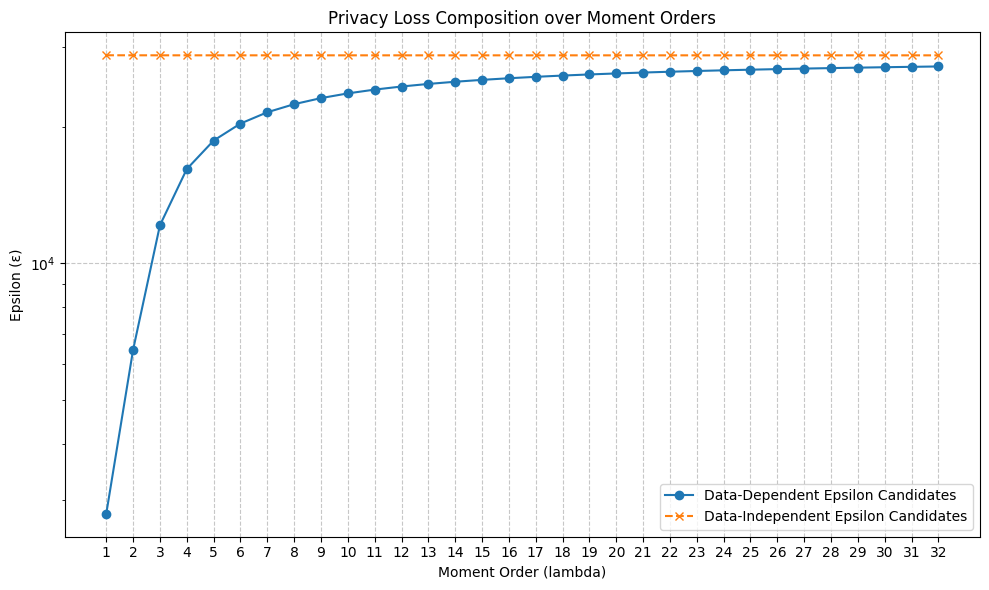

In [ ]:
import matplotlib.pyplot as plt

# Extract data from the results dictionary
moment_orders = results['privacy_results']['moment_orders']
data_dependent_epsilon_candidates = results['privacy_results']['dependent_epsilon_candidates']
data_independent_epsilon_candidates = results['privacy_results']['independent_epsilon_candidates']

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(moment_orders, data_dependent_epsilon_candidates, label='Data-Dependent Epsilon Candidates', marker='o', linestyle='-')
plt.plot(moment_orders, data_independent_epsilon_candidates, label='Data-Independent Epsilon Candidates', marker='x', linestyle='--')

# Add labels and title
plt.xlabel('Moment Order (lambda)')
plt.ylabel('Epsilon (ε)')
plt.title('Privacy Loss Composition over Moment Orders')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale('log') # Use a log scale for better visualization of differences
plt.xticks(moment_orders)
plt.tight_layout()
plt.show()

per query privacy loss

In [ ]:
data_dependent_epsilon = results['privacy_results']['data_dependent_epsilon']
data_independent_epsilon = results['privacy_results']['data_independent_epsilon']

privacy_savings = data_independent_epsilon - data_dependent_epsilon

print(f"Data-Dependent Epsilon: {data_dependent_epsilon:.6f}")
print(f"Data-Independent Epsilon: {data_independent_epsilon:.6f}")
print(f"\nPrivacy Budget Savings (Data-Independent - Data-Dependent): {privacy_savings:.6f}")

Data-Dependent Epsilon: 2803.315187
Data-Independent Epsilon: 28735.559779

Privacy Budget Savings (Data-Independent - Data-Dependent): 25932.244592


### Sensitivity Analysis: Impact of Number of Teachers

This section will re-run the PATE experiment with a varying number of teachers to observe the effect on privacy parameters (data-dependent and data-independent epsilon) and the final student model's accuracy.

In [ ]:
# Define the range of teacher counts to test
num_teachers_values = [3, 4,6, 10]

# List to store results for each configuration
sensitivity_analysis_results = []

# Helper function to generate teacher architectures based on the count
def generate_architectures(count):
    base_archs = ['LSTM', 'GRU', 'CNN']
    return [base_archs[i % len(base_archs)] for i in range(count)]

print(f"Preparing to run sensitivity analysis for teacher counts: {num_teachers_values}")

Preparing to run sensitivity analysis for teacher counts: [3, 4, 6, 10]


In [ ]:
# Store original global values if needed later (though not explicitly requested by user)
_original_num_teachers = NUM_TEACHERS
_original_teacher_architectures = TEACHER_ARCHITECTURES

for num_teachers_val in num_teachers_values:
    print(f"\n{'='*80}")
    print(f"RUNNING EXPERIMENT WITH {num_teachers_val} TEACHERS")
    print(f"{'='*80}")

    # Update global configuration variables (these are used by run_full_pate_experiment)
    global NUM_TEACHERS
    global TEACHER_ARCHITECTURES

    NUM_TEACHERS = num_teachers_val
    TEACHER_ARCHITECTURES = generate_architectures(num_teachers_val)

    print(f"Updated NUM_TEACHERS: {NUM_TEACHERS}")
    print(f"Updated TEACHER_ARCHITECTURES: {TEACHER_ARCHITECTURES}")

    # Re-run the full PATE experiment
    # The run_full_pate_experiment function uses the global NUM_TEACHERS and TEACHER_ARCHITECTURES
    current_experiment_results = run_full_pate_experiment()

    # Extract and store relevant metrics
    sensitivity_analysis_results.append({
        'num_teachers': num_teachers_val,
        'data_dependent_epsilon': current_experiment_results['privacy_results']['data_dependent_epsilon'],
        'data_independent_epsilon': current_experiment_results['privacy_results']['data_independent_epsilon'],
        'student_accuracy': current_experiment_results['final_metrics']['accuracy'],
        'student_f1_macro': current_experiment_results['final_metrics']['f1_macro'],
        'mean_vote_margin': np.mean(current_experiment_results['privacy_results']['vote_margins']) # Added Mean Vote Margin
    })

# Restore original global values after the loop if desired (optional, based on request)
# NUM_TEACHERS = _original_num_teachers
# TEACHER_ARCHITECTURES = _original_teacher_architectures

print("\nSensitivity analysis complete. Results stored in 'sensitivity_analysis_results'.")


RUNNING EXPERIMENT WITH 3 TEACHERS
Updated NUM_TEACHERS: 3
Updated TEACHER_ARCHITECTURES: ['LSTM', 'GRU', 'CNN']
Original shape: (123117, 84)
Filtered shape: (110517, 84)

Class distribution before encoding:
Attack_type
DOS_SYN_Hping     94659
Thing_Speak        8108
ARP_poisioning     7750
Name: count, dtype: int64

Dropping non-numeric columns: ['proto', 'service']

Final partition sizes (unscaled):
Teacher pool: 77361
Student private: 11052
Public: 11052
Final test: 11052

Final partition sizes (scaled):
Teacher pool: 77361
Student private: 11052
Public: 11052
Final test: 11052

Number of classes: 3
Input features: 81
Encoded classes: ['ARP_poisioning', 'DOS_SYN_Hping', 'Thing_Speak']
Teacher 1: train=46281, valid=7737
Teacher 2: train=46407, valid=7737
Teacher 3: train=46452, valid=7737

TRAINING TEACHER 1: LSTM
Epoch 01/30 | Train Loss=0.77419 | Valid Loss=0.61021 | Valid Acc=0.8944
Epoch 02/30 | Train Loss=0.41308 | Valid Loss=0.23279 | Valid Acc=0.9820
Epoch 03/30 | Train Loss=

In [ ]:
results_df = pd.DataFrame(sensitivity_analysis_results)
display(results_df.head())

,num_teachers,data_dependent_epsilon,data_independent_epsilon,student_accuracy,student_f1_macro,mean_vote_margin
0,3,2817.477719,28735.559779,0.983532,0.923249,2.987875
1,4,847.857823,28735.559779,0.990952,0.957939,3.982447
2,6,169.960459,28735.559779,0.991585,0.961064,5.962179
3,10,97.766212,28735.559779,0.990861,0.957517,9.914405


line plot poison mean vote margin

In [ ]:
summary_table = results_df[['num_teachers', 'student_accuracy', 'student_f1_macro', 'data_dependent_epsilon', 'data_independent_epsilon']]
summary_table.rename(columns={'num_teachers': 'Num Teachers', 'student_accuracy': 'Student Accuracy', 'student_f1_macro': 'Student F1-Macro', 'data_dependent_epsilon': 'Epsilon_DD', 'data_independent_epsilon': 'Epsilon_DI'}, inplace=True)
display(summary_table)

,Num Teachers,Student Accuracy,Student F1-Macro,Epsilon_DD,Epsilon_DI
0,3,0.983532,0.923249,2817.477719,28735.559779
1,4,0.990952,0.957939,847.857823,28735.559779
2,6,0.991585,0.961064,169.960459,28735.559779
3,10,0.990861,0.957517,97.766212,28735.559779


### Correlation: Mean Vote Margin vs. Student Accuracy

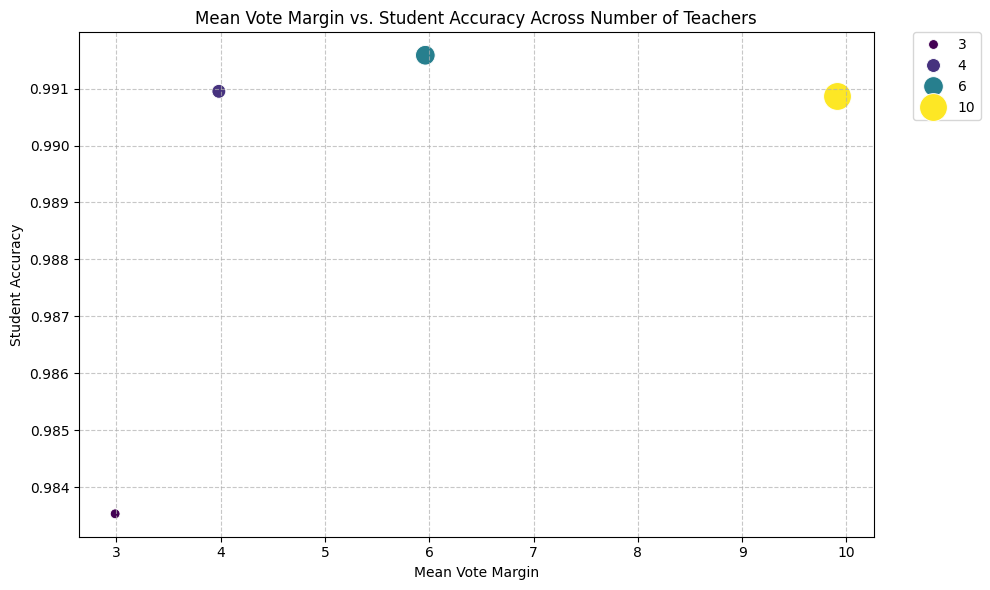

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='mean_vote_margin', y='student_accuracy', data=results_df, hue='num_teachers', size='num_teachers', sizes=(50, 400), palette='viridis', legend='full')
plt.title('Mean Vote Margin vs. Student Accuracy Across Number of Teachers')
plt.xlabel('Mean Vote Margin')
plt.ylabel('Student Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [ ]:
correlation = results_df['mean_vote_margin'].corr(results_df['student_accuracy'])
print(f"Pearson correlation between Mean Vote Margin and Student Accuracy: {correlation:.4f}")

Pearson correlation between Mean Vote Margin and Student Accuracy: -0.3365


### Best Performing Configurations by Privacy (Epsilon) and Accuracy

In [ ]:
best_configurations_df = results_df.sort_values(by=['data_dependent_epsilon', 'student_accuracy'], ascending=[True, False])
display(best_configurations_df)

,num_teachers,data_dependent_epsilon,data_independent_epsilon,student_accuracy,student_f1_macro,mean_vote_margin
3,10,97.766212,28735.559779,0.990861,0.957517,9.914405
2,6,169.960459,28735.559779,0.991585,0.961064,5.962179
1,4,847.857823,28735.559779,0.990952,0.957939,3.982447
0,3,2817.477719,28735.559779,0.983532,0.923249,2.987875


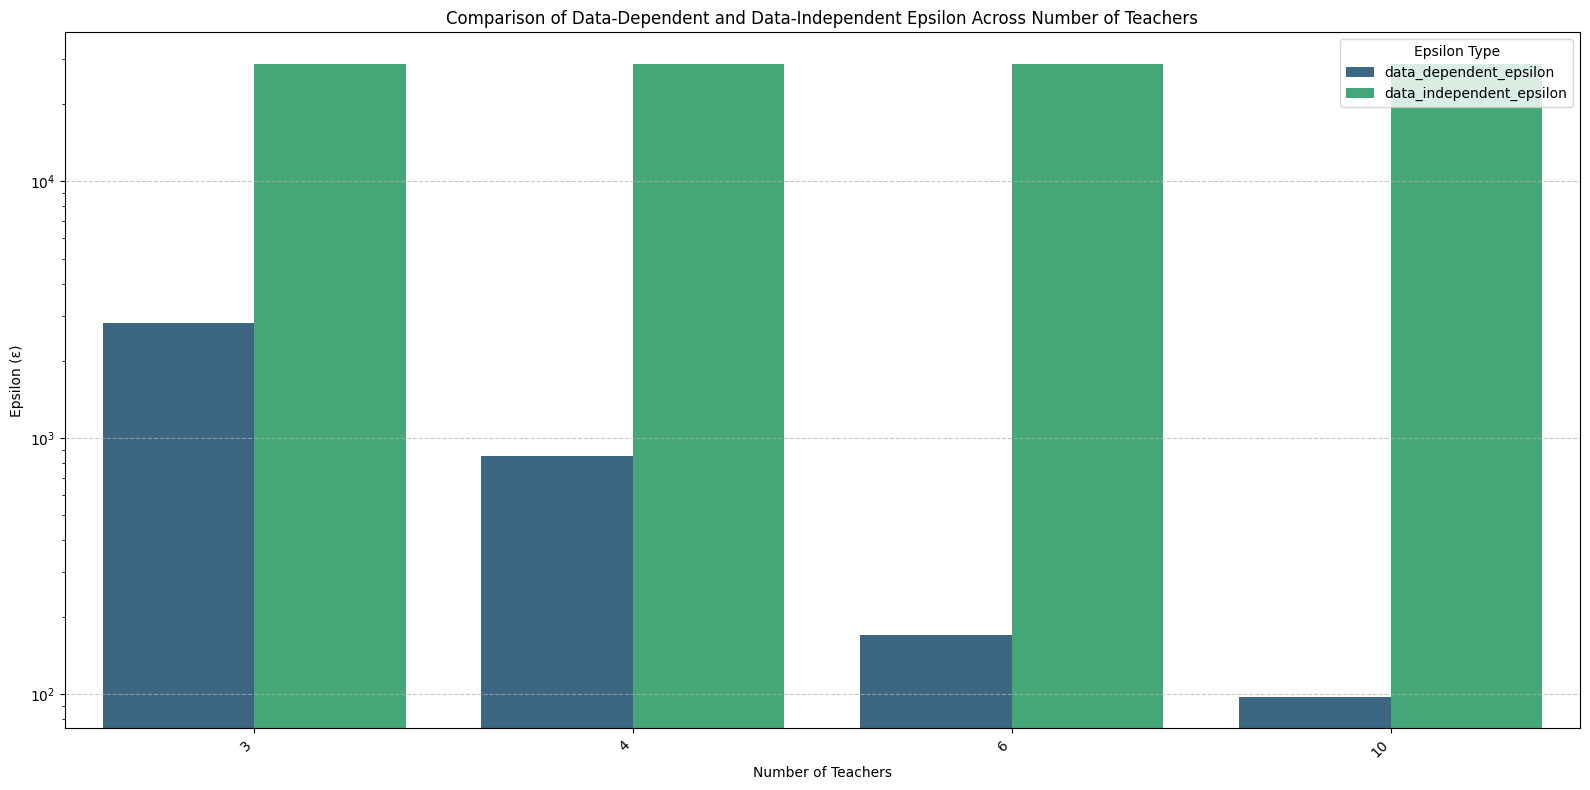

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting: melt the DataFrame to have 'Epsilon Type' and 'Epsilon Value' columns
epsilon_melted_df = results_df.melt(
    id_vars=['num_teachers'],
    value_vars=['data_dependent_epsilon', 'data_independent_epsilon'],
    var_name='Epsilon Type',
    value_name='Epsilon Value'
)

plt.figure(figsize=(16, 8))
sns.barplot(
    x='num_teachers',
    y='Epsilon Value',
    hue='Epsilon Type',
    data=epsilon_melted_df,
    palette='viridis'
)
plt.xlabel('Number of Teachers')
plt.ylabel('Epsilon (ε)')
plt.title('Comparison of Data-Dependent and Data-Independent Epsilon Across Number of Teachers')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.yscale('log') # Use a log scale for better visualization due to large differences
plt.legend(title='Epsilon Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

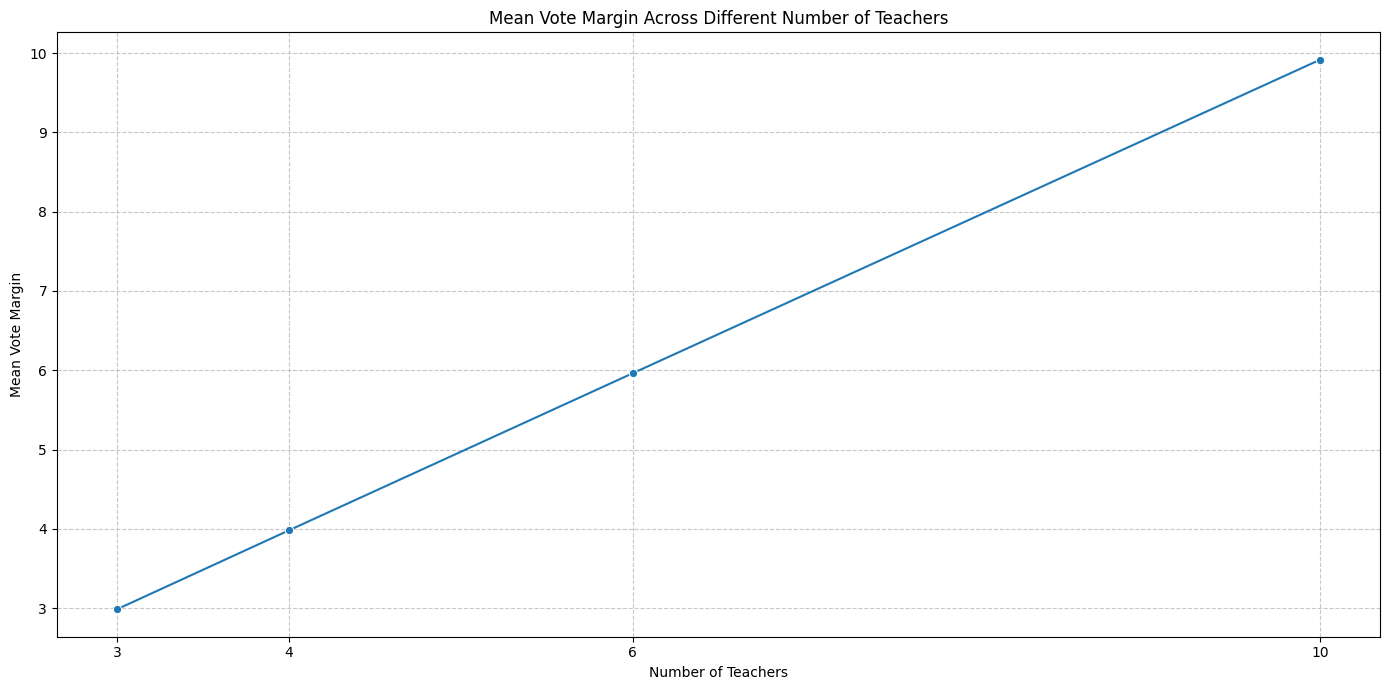

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='num_teachers', y='mean_vote_margin', data=results_df, marker='o', linestyle='-')
plt.xlabel('Number of Teachers')
plt.ylabel('Mean Vote Margin')
plt.title('Mean Vote Margin Across Different Number of Teachers')
plt.xticks(results_df['num_teachers'].unique()) # Ensure all teacher counts are shown
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Student Accuracy vs. Number of Teachers

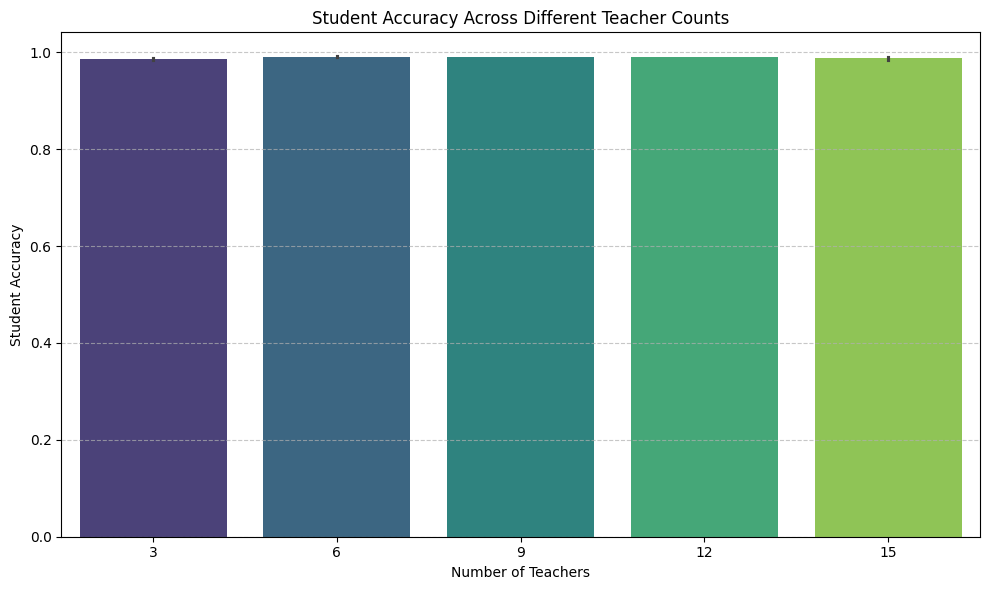

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure sensitivity_df exists; if not, re-create from sensitivity_analysis_results
if 'sensitivity_df' not in locals() and 'sensitivity_analysis_results' in locals():
    sensitivity_df = pd.DataFrame(sensitivity_analysis_results)

plt.figure(figsize=(10, 6))
sns.barplot(x='num_teachers', y='student_accuracy', data=sensitivity_df, palette='viridis')
plt.xlabel('Number of Teachers')
plt.ylabel('Student Accuracy')
plt.title('Student Accuracy Across Different Teacher Counts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Confusion Matrix for 15 Teachers Configuration

Confusion Matrix for 15 Teachers:
[[ 747    0   28]
 [   0 9467    0]
 [  73    0  737]]


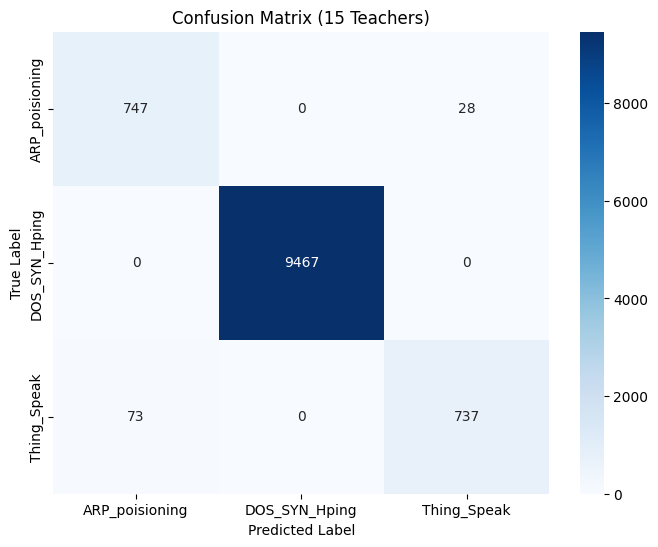

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `current_experiment_results` holds the results for the 15 teachers configuration
confusion_matrix_15_teachers = current_experiment_results['confusion_matrix']

# The LabelEncoder sorts classes alphabetically. We can derive them from SELECTED_CLASSES.
label_encoder_classes = sorted(SELECTED_CLASSES)

print("Confusion Matrix for 15 Teachers:")
print(confusion_matrix_15_teachers)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_15_teachers, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_classes, yticklabels=label_encoder_classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (15 Teachers)')
plt.show()

### Correlation: Number of Teachers vs. Data-Dependent Epsilon

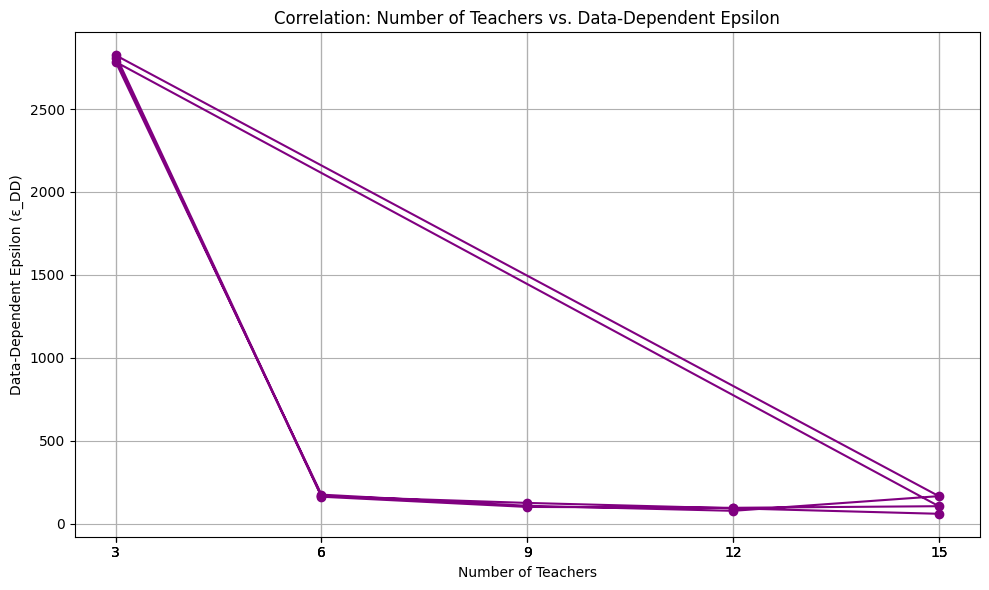

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure sensitivity_df exists; if not, re-create from sensitivity_analysis_results
if 'sensitivity_df' not in locals() and 'sensitivity_analysis_results' in locals():
    sensitivity_df = pd.DataFrame(sensitivity_analysis_results)

plt.figure(figsize=(10, 6))
plt.plot(sensitivity_df['num_teachers'], sensitivity_df['data_dependent_epsilon'], marker='o', linestyle='-', color='purple')
plt.xlabel('Number of Teachers')
plt.ylabel('Data-Dependent Epsilon (ε_DD)')
plt.title('Correlation: Number of Teachers vs. Data-Dependent Epsilon')
plt.grid(True)
plt.xticks(sensitivity_df['num_teachers'])
plt.tight_layout()
plt.show()

### Summary of Architectural Configuration Analysis

In [ ]:
display(results_df)

,num_teachers,data_dependent_epsilon,data_independent_epsilon,student_accuracy,student_f1_macro,mean_vote_margin
0,3,2817.477719,28735.559779,0.983532,0.923249,2.987875
1,4,847.857823,28735.559779,0.990952,0.957939,3.982447
2,6,169.960459,28735.559779,0.991585,0.961064,5.962179
3,10,97.766212,28735.559779,0.990861,0.957517,9.914405
